In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
from google.colab import userdata
token =userdata.get('Cryptonite-Token')

In [12]:
!git config --global user.email "idantsri2007@gmail.com"
!git config --global user.name "SILETRO"

In [13]:
!git clone https://{token}@github.com/SILETRO/Cryptonite-JM-Tasks.git
%cd Cryptonite-JM-Tasks

Cloning into 'Cryptonite-JM-Tasks'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 119 (delta 37), reused 82 (delta 25), pack-reused 17 (from 1)
Receiving objects: 100% (119/119), 72.41 MiB | 14.38 MiB/s, done.
Resolving deltas: 100% (37/37), done.
/content/Cryptonite-JM-Tasks/Cryptonite-JM-Tasks


In [14]:
!cp '/content/drive/MyDrive/Colab Notebooks/Kaggle_heart.ipynb' 'Kaggle Comp'/

In [15]:
!git add .

In [16]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   Kaggle Comp/Kaggle_heart.ipynb



In [ ]:
!git commit -m "Kaggle heart"
!git push -u origin main

[main bf2d808] Kaggle heart
 1 file changed, 1 insertion(+), 3059 deletions(-)
 rewrite Kaggle Comp/Kaggle_heart.ipynb (97%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 12.76 KiB | 4.25 MiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/SILETRO/Cryptonite-JM-Tasks.git
   94df05e..bf2d808  main -> main
Branch 'main' set up to track remote branch 'main' from 'origin'.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/train.csv')

In [ ]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152.0,239.0,0.0,0.0,158.0,1.0,3.6,2.0,2.0,7.0,Presence
1,1,52,1,1,125.0,325.0,0.0,2.0,171.0,0.0,0.0,1.0,0.0,3.0,Absence
2,2,56,0,2,160.0,188.0,0.0,2.0,151.0,0.0,0.0,1.0,0.0,3.0,Absence
3,3,44,0,3,134.0,229.0,0.0,2.0,150.0,0.0,1.0,2.0,0.0,3.0,Absence
4,4,58,1,4,140.0,234.0,0.0,2.0,125.0,1.0,3.8,2.0,3.0,3.0,Presence


In [ ]:
df.shape

(85066, 15)

In [ ]:
y = df['Heart Disease']
X = df.drop(['Heart Disease','id'],axis=1)

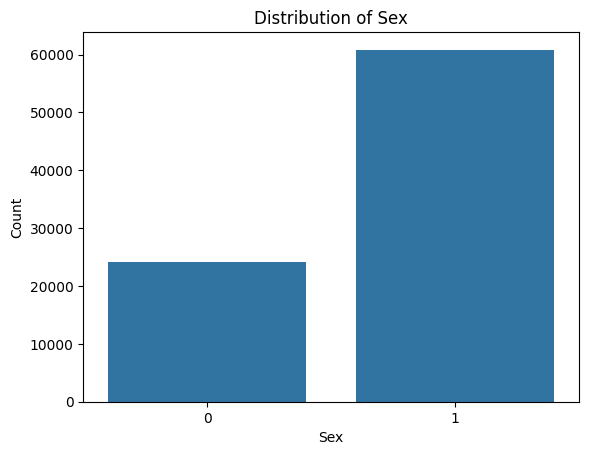

In [ ]:
sns.countplot(x='Sex', data=X)
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

In [ ]:
X.isna().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,1
Cholesterol,1
FBS over 120,1
EKG results,1
Max HR,1
Exercise angina,1
ST depression,1


In [ ]:
y.isna().sum()

np.int64(1)

## KFold

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

In [ ]:
def engineer_features(data):
    # Log transform skewed features
    data['ST depression'] = np.log1p(data['ST depression'])
    data['BP'] = np.log1p(data['BP'])

    # Interaction Features
    data['RPP'] = data['Max HR'] * data['BP']
    data['ST_Slope_Interaction'] = data['ST depression'] * data['Slope of ST']
    data['BP_to_MaxHR'] = data['BP'] / data['Max HR']
    data['Age_Sex'] = data['Age'] * data['Sex']
    return data

In [ ]:
df = pd.read_csv('train.csv')
X = df.drop(['id', 'Heart Disease'], axis=1)
y = df['Heart Disease'].map({'Presence': 1, 'Absence': 0}).values

X = engineer_features(X)


In [ ]:
numeric_features = [
    'Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression',
    'RPP', 'ST_Slope_Interaction', 'BP_to_MaxHR', 'Age_Sex',
    'Sex', 'Exercise angina', 'FBS over 120', 'Number of vessels fluro', 'Slope of ST'
]
categorical_features = ['Chest pain type', 'Thallium', 'EKG results']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

In [ ]:
y = df['Heart Disease'].map({'Presence': 1, 'Absence': 0}).values

nan_in_X = X.isna().any(axis=1)
nan_in_y = np.isnan(y)

# Combine indices where NaN values exist in either X or y
combined_nan_indices = nan_in_X | nan_in_y

if np.any(combined_nan_indices):
    initial_nan_count = combined_nan_indices.sum()
    print(f"Found {initial_nan_count} rows with NaN values in X or y. Removing corresponding rows from X and y.")

    # Remove corresponding rows from X and y
    X = X[~combined_nan_indices]
    y = y[~combined_nan_indices]
else:
    print("No NaN values found in X or y.")

FOLDS = 5
kfold = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

Found 1 rows with NaN values in X or y. Removing corresponding rows from X and y.


In [ ]:
import xgboost as xgb
from xgboost.callback import EarlyStopping

xgb_oof = np.zeros(len(y))

for fold, (tr, va) in enumerate(kfold.split(X, y)):
    print(f"XGB Fold {fold+1}")

    X_tr_fold, X_va_fold = X.iloc[tr], X.iloc[va] # Get the DataFrame subsets for the current fold
    y_tr, y_va = y[tr], y[va]

    # Instantiate a fresh preprocessor for each fold to prevent data leakage
    fold_preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

    # Fit preprocessor only on the training data of the current fold
    X_tr_processed = fold_preprocessor.fit_transform(X_tr_fold)
    # Transform both training and validation data using the fitted preprocessor
    X_va_processed = fold_preprocessor.transform(X_va_fold)
    xgb_params_balanced = {
        'objective': 'binary:logistic',
        'device': 'cuda',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'max_depth': 5,
        'learning_rate': 0.06,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'min_child_weight': 30,
        'gamma': 0.1,
        # 'reg_alpha': 0.1,
        'reg_lambda': 0.5,
        'n_estimators': 3000,
        'task_type':'GPU',
        'random_state': 42,
        'n_jobs': -1
    }

    xgb_model = xgb.XGBClassifier(**xgb_params_balanced)

    xgb_model.fit(
        X_tr_processed, y_tr,
        eval_set=[(X_va_processed, y_va)],
        verbose=False

    )
    xgb_oof[va] = xgb_model.predict_proba(X_va_processed)[:,1]
    print("AUC:", roc_auc_score(y_va, xgb_oof[va]))

XGB Fold 1


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:55:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "task_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [08:55:11] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


AUC: 0.9518633791233526
XGB Fold 2


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:55:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "task_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9515226923247591
XGB Fold 3


...

AUC: 0.9497954933185466
XGB Fold 4


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:55:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "task_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9513897760177142
XGB Fold 5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:55:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "task_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9519931477870334


In [ ]:
import sys
!{sys.executable} -m pip install catboost

from catboost import CatBoostClassifier

cat_oof = np.zeros(len(y))

for fold, (tr, va) in enumerate(kfold.split(X, y)):
    print(f"CAT Fold {fold+1}")

    X_tr_fold, X_va_fold = X.iloc[tr], X.iloc[va]
    y_tr, y_va = y[tr], y[va]

    fold_preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

    X_tr_processed = fold_preprocessor.fit_transform(X_tr_fold)
    X_va_processed = fold_preprocessor.transform(X_va_fold)

    cat_params_balanced = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'devices':'0',
        'iterations': 3000,
        'learning_rate': 0.05,
        'depth': 8,
        'l2_leaf_reg': 5,
        'boosting_type': 'Ordered',
        'bootstrap_type': 'Bernoulli',
        'subsample': 0.7,
        'random_seed': 42,
        'verbose': False,
        'task_type': 'GPU',
        'thread_count': -1
    }
    cat_model = CatBoostClassifier(**cat_params_balanced)

    cat_model.fit(
        X_tr_processed, y_tr,
        eval_set=(X_va_processed, y_va),
        early_stopping_rounds=200
    )

    cat_oof[va] = cat_model.predict_proba(X_va_processed)[:,1]
    print("AUC:", roc_auc_score(y_va, cat_oof[va]))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.6 MB/s eta 0:00:00
CAT Fold 1


Default metric period is 5 because AUC is/are not implemented for GPU


AUC: 0.9556205867827828
CAT Fold 2


Default metric period is 5 because AUC is/are not implemented for GPU


AUC: 0.9553792334969318
CAT Fold 3


...

AUC: 0.953607877833223
CAT Fold 4


Default metric period is 5 because AUC is/are not implemented for GPU


AUC: 0.9552738339590687
CAT Fold 5


Default metric period is 5 because AUC is/are not implemented for GPU


AUC: 0.9553447174970122


In [ ]:
from sklearn.linear_model import LogisticRegression

stack_train = np.column_stack([
    xgb_oof,
    cat_oof,
])

meta = LogisticRegression()
meta.fit(stack_train, y)

final_oof = meta.predict_proba(stack_train)[:,1]

print("FINAL STACKED AUC:",
      roc_auc_score(y, final_oof))

FINAL STACKED AUC: 0.9550753440580677


In [ ]:
print("XGB AUC:", roc_auc_score(y, xgb_oof))
print("CAT AUC:", roc_auc_score(y, cat_oof))

XGB AUC: 0.9513084969515355
CAT AUC: 0.9550368411661968


In [ ]:
X_final = pd.read_csv('/content/test.csv')
test_ids = X_final['id']
X_final_to_process = X_final.drop('id', axis=1).copy()
X_final_engineered = engineer_features(X_final_to_process)
display(X_final_to_process.head())

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,RPP,ST_Slope_Interaction,BP_to_MaxHR,Age_Sex
0,58,1,3,4.795791,288,0,2,145,1,0.587787,2,3,3,695.389629,1.175573,0.033074,58
1,55,0,2,4.795791,209,0,0,172,0,0.000000,1,0,3,824.875974,0.000000,0.027883,0
2,54,1,4,4.795791,268,0,0,150,1,0.000000,2,3,7,719.368582,0.000000,0.031972,54
3,44,0,3,4.727388,177,0,0,168,0,0.641854,1,0,3,794.201154,0.641854,0.028139,0
4,43,1,1,4.934474,267,0,0,163,0,1.029619,2,0,7,804.319251,2.059239,0.030273,43


In [ ]:
from sklearn.linear_model import LogisticRegression

stack_train_meta = np.column_stack([
    xgb_oof,
    cat_oof
])

meta_model = LogisticRegression(random_state=42)
meta_model.fit(stack_train_meta, y)

final_oof = meta_model.predict_proba(stack_train_meta)[:, 1]

print("Logistic Regression meta-model trained successfully using xgb_oof and cat_oof.")
print("New Stacked OOF AUC:", roc_auc_score(y, final_oof))

Logistic Regression meta-model trained successfully using xgb_oof and cat_oof.
New Stacked OOF AUC: 0.9550753440580677


In [ ]:
X_processed = preprocessor.fit_transform(X)
X_final_processed = preprocessor.transform(X_final_engineered)

print("X_processed and X_final_processed have been created.")

X_processed and X_final_processed have been created.


In [ ]:
# Retrain CatBoost model on the entire dataset
cat_model_final = CatBoostClassifier(**cat_params_balanced)
cat_model_final.fit(X_processed, y)
print("CatBoost model retrained successfully on full data.")

Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost model retrained successfully on full data.


In [ ]:
cat_test = cat_model_final.predict_proba(X_final_processed)[:, 1]

In [ ]:
!pip install optuna

In [ ]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from xgboost.callback import EarlyStopping # Removed as it's causing issues with current fit method

def objective_xgb(trial):
    # Split data for this trial. Note: X and y are already defined in the notebook.
    X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Create a fresh preprocessor for each trial to ensure proper fitting and avoid data leakage
    preprocessor_for_trial = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

    # Fit the preprocessor on the training data and transform both training and validation data
    X_train_processed = preprocessor_for_trial.fit_transform(X_train_tune)
    X_val_processed = preprocessor_for_trial.transform(X_val_tune)

    # Hyperparameters to tune for XGBoost
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'device': 'cuda',
        'n_estimators': trial.suggest_int('n_estimators', 1000, 4000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    xgb_model = xgb.XGBClassifier(**param)

    # Removed callbacks argument, n_estimators will control boosting rounds
    xgb_model.fit(X_train_processed, y_train_tune,
                  eval_set=[(X_val_processed, y_val_tune)],
                  verbose=False) # Keep verbose=False to suppress output

    preds = xgb_model.predict_proba(X_val_processed)[:, 1]
    auc = roc_auc_score(y_val_tune, preds)

    return auc

print("XGBoost Optuna objective function defined (callbacks removed).")

XGBoost Optuna objective function defined (callbacks removed).


In [ ]:
print("Running Optuna study for XGBoost...")
study_xgb = optuna.create_study(direction='maximize', study_name='xgb_optimization_final_attempt')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

xgb_best_params = study_xgb.best_params
xgb_best_auc = study_xgb.best_value

print("Best XGBoost hyperparameters found:", xgb_best_params)
print("Best XGBoost AUC score:", xgb_best_auc)

In [ ]:
xgb_best_params['device'] = 'cuda'
xgb_best_params['tree_method'] = 'hist'

xgb_model_final_optimized = xgb.XGBClassifier(**xgb_best_params)
xgb_model_final_optimized.fit(X_processed, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7008979004886333, device='cuda',
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.02243133163328756, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.016165397038256837,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=50, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2373, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_test_optimized = xgb_model_final_optimized.predict_proba(X_final_processed)[:, 1]

In [ ]:
stack_test_optimized = np.column_stack([
    xgb_test_optimized,
    cat_test
])

print("Optimized test predictions stacked for meta-model input.")

Optimized test predictions stacked for meta-model input.


In [ ]:
final_test_predictions_optimized_xgb = meta_model.predict_proba(stack_test_optimized)[:, 1]

print("Final stacked predictions generated using the meta-model with optimized XGBoost.")

Final stacked predictions generated using the meta-model with optimized XGBoost.


In [ ]:
submission_df_optimized_xgb = pd.DataFrame({
    'id': test_ids,
    'Heart Disease': final_test_predictions_optimized_xgb
})

submission_df_optimized_xgb.to_csv('submission_optimized_xgb.csv', index=False)

print("Submission file 'submission_optimized_xgb.csv' created successfully.")

Submission file 'submission_optimized_xgb.csv' created successfully.


In [ ]:
from sklearn.metrics import roc_auc_score
from scipy.optimize import minimize

def auc_loss_func(weights, oof_preds, y_true):
    # Blend the predictions using the provided weights
    blended_predictions = np.zeros_like(oof_preds[0])
    for i, weight in enumerate(weights):
        blended_predictions += weight * oof_preds[i]

    # Calculate the AUC score
    auc_score = roc_auc_score(y_true, blended_predictions)

    # Return the negative AUC score for minimization
    return -auc_score

print("auc_loss_func defined successfully and necessary libraries imported.")

auc_loss_func defined successfully and necessary libraries imported.


In [ ]:
from sklearn.metrics import roc_auc_score
from scipy.optimize import minimize

def auc_loss_func(weights, oof_preds, y_true):
    # Blend the predictions using the provided weights
    blended_predictions = np.zeros_like(oof_preds[0])
    for i, weight in enumerate(weights):
        blended_predictions += weight * oof_preds[i]

    # Calculate the AUC score
    auc_score = roc_auc_score(y_true, blended_predictions)

    # Return the negative AUC score for minimization
    return -auc_score

initial_weights = np.array([0.5, 0.5]) # Initial guess for weights

oof_predictions_to_blend = [xgb_oof, cat_oof]

# Define bounds for weights (each weight between 0 and 1)
bounds = [(0.0, 1.0) for _ in range(len(oof_predictions_to_blend))]

# Define constraints: sum of weights must be 1
constraints = ({'type': 'eq', 'fun': lambda w: 1.0 - np.sum(w)})

# Minimize the negative AUC to maximize AUC
optimal_result = minimize(
    auc_loss_func,
    initial_weights,
    args=(oof_predictions_to_blend, y),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimized_weights = optimal_result.x
optimized_auc = -optimal_result.fun

print(f"Optimized blending weights for [XGBoost, CatBoost]: {optimized_weights}")
print(f"Maximized AUC with optimized weights: {optimized_auc:.6f}")

Optimized blending weights for [XGBoost, CatBoost]: [0.42771811 0.57228189]
Maximized AUC with optimized weights: 0.954607


In [ ]:
test_predictions_to_blend = [xgb_test_optimized, cat_test]

final_blended_test_predictions = np.zeros_like(test_predictions_to_blend[0])
for i, weight in enumerate(optimized_weights):
    final_blended_test_predictions += weight * test_predictions_to_blend[i]

submission_df_weighted_blend = pd.DataFrame({
    'id': test_ids,
    'Heart Disease': final_blended_test_predictions
})

submission_df_weighted_blend.to_csv('submission_weighted_blend.csv', index=False)

print("Submission file 'submission_weighted_blend.csv' created successfully with optimized blending weights.")

Submission file 'submission_weighted_blend.csv' created successfully with optimized blending weights.


In [ ]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def objective_catboost(trial):
    # Split data for this trial.
    X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Create a fresh preprocessor for each trial to ensure proper fitting and avoid data leakage
    preprocessor_for_trial = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

    # Fit the preprocessor on the training data and transform both training and validation data
    X_train_processed = preprocessor_for_trial.fit_transform(X_train_tune)
    X_val_processed = preprocessor_for_trial.transform(X_val_tune)

    # Hyperparameters to tune for CatBoost
    param = {
        'iterations': trial.suggest_int('iterations', 500, 4000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 2.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'loss_function': 'Logloss',
        'eval_metric': 'Logloss',
        'task_type': 'GPU',
        'devices': '0',
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 200
    }

    cat_model = CatBoostClassifier(**param)

    cat_model.fit(
        X_train_processed, y_train_tune,
        eval_set=(X_val_processed, y_val_tune),
        early_stopping_rounds=param['early_stopping_rounds']
    )

    preds = cat_model.predict_proba(X_val_processed)[:, 1]
    auc = roc_auc_score(y_val_tune, preds)

    return auc

print("CatBoost Optuna objective function defined.")

CatBoost Optuna objective function defined.


In [ ]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def objective_catboost(trial):
    # Split data for this trial.
    X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Create a fresh preprocessor for each trial to ensure proper fitting and avoid data leakage
    preprocessor_for_trial = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

    # Fit the preprocessor on the training data and transform both training and validation data
    X_train_processed = preprocessor_for_trial.fit_transform(X_train_tune)
    X_val_processed = preprocessor_for_trial.transform(X_val_tune)

    # Hyperparameters to tune for CatBoost
    param = {
        'iterations': trial.suggest_int('iterations', 500, 4000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 2.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'loss_function': 'Logloss',
        'eval_metric': 'Logloss',
        'task_type': 'GPU',
        'devices': '0',
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 200,
        'bootstrap_type': 'Bernoulli' # Explicitly setting bootstrap_type
    }

    cat_model = CatBoostClassifier(**param)

    cat_model.fit(
        X_train_processed, y_train_tune,
        eval_set=(X_val_processed, y_val_tune),
        early_stopping_rounds=param['early_stopping_rounds']
    )

    preds = cat_model.predict_proba(X_val_processed)[:, 1]
    auc = roc_auc_score(y_val_tune, preds)

    return auc

print("CatBoost Optuna objective function defined with 'Bernoulli' bootstrap_type.")

CatBoost Optuna objective function defined with 'Bernoulli' bootstrap_type.


In [ ]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def objective_catboost(trial):
    # Split data for this trial.
    X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Create a fresh preprocessor for each trial to ensure proper fitting and avoid data leakage
    preprocessor_for_trial = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

    # Fit the preprocessor on the training data and transform both training and validation data
    X_train_processed = preprocessor_for_trial.fit_transform(X_train_tune)
    X_val_processed = preprocessor_for_trial.transform(X_val_tune)

    # Hyperparameters to tune for CatBoost
    param = {
        'iterations': trial.suggest_int('iterations', 500, 4000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 2.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'loss_function': 'Logloss',
        'eval_metric': 'Logloss',
        'task_type': 'GPU',
        'devices': '0',
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 200,
        'bootstrap_type': 'Bernoulli' # Explicitly setting bootstrap_type
    }

    cat_model = CatBoostClassifier(**param)

    cat_model.fit(
        X_train_processed, y_train_tune,
        eval_set=(X_val_processed, y_val_tune),
        early_stopping_rounds=param['early_stopping_rounds']
    )

    preds = cat_model.predict_proba(X_val_processed)[:, 1]
    auc = roc_auc_score(y_val_tune, preds)

    return auc

print("CatBoost Optuna objective function defined with 'Bernoulli' bootstrap_type and colsample_bylevel removed.")

CatBoost Optuna objective function defined with 'Bernoulli' bootstrap_type and colsample_bylevel removed.


In [ ]:
print("Running Optuna study for CatBoost...")
study_cat = optuna.create_study(direction='maximize', study_name='catboost_optimization_fixed_final')
study_cat.optimize(objective_catboost, n_trials=50, show_progress_bar=True)

cat_best_params = study_cat.best_params
cat_best_auc = study_cat.best_value

print("Best CatBoost hyperparameters found:", cat_best_params)
print("Best CatBoost AUC score:", cat_best_auc)

**Reasoning**:
The Optuna study for CatBoost has successfully completed, and the best hyperparameters have been identified. The next step is to retrain the CatBoost model using these optimized parameters on the entire dataset and then generate predictions for the test set.



In [ ]:
final_cat_params = cat_best_params.copy()
if 'early_stopping_rounds' in final_cat_params:
    del final_cat_params['early_stopping_rounds']
final_cat_params['verbose'] = False # Ensure no verbose output during final training
final_cat_params['loss_function'] = 'Logloss'
final_cat_params['eval_metric'] = 'Logloss'
final_cat_params['task_type'] = 'GPU'
final_cat_params['devices'] = '0'
final_cat_params['random_seed'] = 42
final_cat_params['bootstrap_type'] = 'Bernoulli'

cat_model_final_optimized = CatBoostClassifier(**final_cat_params)
cat_model_final_optimized.fit(X_processed, y)
print("CatBoost model retrained successfully on full data with optimized parameters.")

# Generate optimized CatBoost test predictions
cat_test_optimized = cat_model_final_optimized.predict_proba(X_final_processed)[:, 1]
print("Optimized CatBoost test predictions generated.")

CatBoost model retrained successfully on full data with optimized parameters.
Optimized CatBoost test predictions generated.


In [ ]:
final_blended_test_predictions_optimized = np.zeros_like(xgb_test_optimized)
for i, weight in enumerate(optimized_weights):
    final_blended_test_predictions_optimized += weight * [xgb_test_optimized, cat_test_optimized][i]

submission_df_optimized_blend = pd.DataFrame({
    'id': test_ids,
    'Heart Disease': final_blended_test_predictions_optimized
})

submission_df_optimized_blend.to_csv('submission_optimized_final_blend.csv', index=False)

print("Final submission file 'submission_optimized_final_blend.csv' created with optimized weighted blend.")

Final submission file 'submission_optimized_final_blend.csv' created with optimized weighted blend.
